# Travel Reimbursement Approval Agent

**AI Developer Candidate Assignment**

This notebook implements a lightweight, policy-grounded Travel Reimbursement Approval Agent.

### What this demonstrates
- Claim intake from structured Python/JSON data
- Policy retrieval using stable `POL-*` rule IDs
- Multiple meaningful tools/functions
- Agent-style workflow and tool routing
- Deterministic policy enforcement around the LLM
- Structured output validation
- Manual-review routing for ambiguity, missing receipts, exceptions, and high-value claims
- Results dashboard
- Audit trail and sample outputs

> **Design principle:** GenAI can help interpret ambiguous descriptions and explain decisions, but the reimbursement calculation itself is controlled by explicit policy tools. This reduces hallucination and makes the financial result auditable.


In [6]:
%pip install pandas matplotlib pydantic ipywidgets groq

  Using cached matplotlib-3.11.2-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached ipywidgets-8.1.9-py3-none-any.whl.metadata (2.4 kB)
  Using cached contourpy-1.4.0-cp314-cp314-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.66.1-cp314-cp314-win_amd64.whl.metadata (132 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
  Using cached widgetsnbextension-4.0.16-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.17-py3-none-any.whl.metadata (20 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.8 MB 2.9 MB/s eta 0:00:04
   ---- ----------------------------------- 1.0/9.8 MB 2.8 MB/s eta 0:00:04
   ------- -------------------------------- 1.8/9.8 MB 3.2 MB/s eta 0:00:03
   ---------- ----------------------------- 2.6/9.8 


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Setup / README

This notebook runs top-to-bottom and uses **Groq as the optional LLM planner**.

### 1. Install dependencies
In Colab/Jupyter, run:

```bash
pip install pandas matplotlib pydantic ipywidgets groq
```

### 2. Add your Groq API key
Paste your key only in the clearly marked `GROQ_API_KEY` cell below.

> **Important:** Do not commit a real API key to GitHub. Before submitting the notebook, replace it with the placeholder again.

### 3. How the agent works
- Groq reads the structured claim and selects relevant tools.
- Python executes the selected tools.
- A deterministic safety layer adds any mandatory checks the LLM omitted.
- Financial calculations and final policy enforcement remain deterministic.
- If Groq is unavailable, the notebook falls back to the deterministic tool set so the demo still runs.

The five assignment claims are evaluated automatically. The interactive UI is optional.

In [ ]:
import os
import json
from datetime import datetime, date
from typing import Any, Dict, List

import pandas as pd
import matplotlib.pyplot as plt

try:
    from pydantic import BaseModel, Field, ValidationError
    PYDANTIC_AVAILABLE = True
except Exception:
    PYDANTIC_AVAILABLE = False

# ============================================================
# PASTE YOUR GROQ KEY HERE FOR LOCAL/COLAB TESTING ONLY.
# ============================================================
GROQ_API_KEY = "PASTE_YOUR_GROQ_KEY_HERE"

if GROQ_API_KEY and GROQ_API_KEY != "PASTE_YOUR_GROQ_KEY_HERE":
    os.environ["GROQ_API_KEY"] = GROQ_API_KEY

GROQ_MODEL = os.getenv("GROQ_MODEL", "openai/gpt-oss-20b")

print("Python environment ready.")
print("Groq planner:", "ENABLED" if os.getenv("GROQ_API_KEY") else "FALLBACK / DETERMINISTIC")
print("Groq model:", GROQ_MODEL)

Python environment ready.
Groq planner: ENABLED
Groq model: openai/gpt-oss-20b


## 1. Policy Knowledge Base

The policy is represented as structured data so that every financial rule can be traced to a stable policy reference.

Source: assignment Appendix A. fileciteturn0file0L79-L122


In [4]:
POLICY = {
    "categories": {
        "airfare": {"eligible": True, "rule": "POL-CAT-01"},
        "lodging": {"eligible": True, "rule": "POL-CAT-01"},
        "meals": {"eligible": True, "rule": "POL-CAT-01"},
        "ground_transport": {"eligible": True, "rule": "POL-CAT-01"},
        "conference_fees": {"eligible": True, "rule": "POL-CAT-01"},
        "spa": {"eligible": False, "rule": "POL-CAT-02"},
        "minibar": {"eligible": False, "rule": "POL-CAT-02"},
        "personal_entertainment": {"eligible": False, "rule": "POL-CAT-02"},
        "personal_shopping": {"eligible": False, "rule": "POL-CAT-02"},
        "gifts": {"eligible": False, "rule": "POL-CAT-02"},
        "traffic_fine": {"eligible": False, "rule": "POL-CAT-02"},
    },
    "limits": {
        "meals": {"max": 75.0, "basis": "day", "rule": "POL-PD-01"},
        "lodging": {"max": 200.0, "basis": "night", "rule": "POL-PD-02"},
        "ground_transport": {"max": 50.0, "basis": "day", "rule": "POL-PD-03"},
    },
    "airfare": {
        "allowed_classes": ["economy"],
        "exception_rule": "POL-AIR-01",
    },
    "receipts": {
        "threshold": 25.0,
        "above_threshold_rule": "POL-RCT-01",
        "missing_receipt_rule": "POL-RCT-02",
        "always_required": ["airfare", "lodging"],
    },
    "approval": {
        "auto_max": 500.0,
        "manager_max": 2000.0,
        "manual_above": 2000.0,
        "auto_rule": "POL-APR-01",
        "manager_rule": "POL-APR-02",
        "manual_rule": "POL-APR-03",
    },
    "timeliness": {
        "max_days": 30,
        "rule": "POL-TIME-01",
    }
}

## 2. Sample Claims

The five claims below are the exact assignment inputs. fileciteturn0file0L126-L163


In [5]:
CLAIMS = [
    {
        "claim_id": "CLM-001",
        "employee": "A. Rivera",
        "trip_start": "2026-06-10",
        "trip_end": "2026-06-12",
        "submitted": "2026-06-20",
        "items": [
            {"category":"airfare", "description":"Round-trip economy airfare", "amount":420.00, "receipt":True},
            {"category":"lodging", "description":"Hotel, 2 nights @ $180", "amount":360.00, "receipt":True, "units":2},
            {"category":"meals", "description":"Meals, 3 days @ ~$60/day", "amount":180.00, "receipt":True, "units":3},
            {"category":"conference_fees", "description":"Conference registration", "amount":150.00, "receipt":True},
        ],
    },
    {
        "claim_id": "CLM-002",
        "employee": "B. Osei",
        "trip_start": "2026-06-14",
        "trip_end": "2026-06-15",
        "submitted": "2026-06-25",
        "items": [
            {"category":"spa", "description":"Hotel spa package", "amount":300.00, "receipt":True},
            {"category":"minibar", "description":"In-room minibar", "amount":80.00, "receipt":True},
        ],
    },
    {
        "claim_id": "CLM-003",
        "employee": "C. Nakamura",
        "trip_start": "2026-06-08",
        "trip_end": "2026-06-10",
        "submitted": "2026-06-22",
        "items": [
            {"category":"airfare", "description":"Round-trip economy airfare", "amount":300.00, "receipt":True},
            {"category":"lodging", "description":"Hotel, 2 nights @ $250", "amount":500.00, "receipt":True, "units":2},
            {"category":"meals", "description":"Meals, 2 days @ $70/day", "amount":140.00, "receipt":True, "units":2},
        ],
    },
    {
        "claim_id": "CLM-004",
        "employee": "D. Fischer",
        "trip_start": "2026-06-16",
        "trip_end": "2026-06-18",
        "submitted": "2026-06-28",
        "items": [
            {"category":"airfare", "description":"Business-class international airfare", "amount":2400.00, "receipt":True, "airfare_class":"business"},
            {"category":"lodging", "description":"Hotel, 3 nights", "amount":600.00, "receipt":False, "units":3},
        ],
    },
    {
        "claim_id": "CLM-005",
        "employee": "E. Haddad",
        "trip_start": "2026-06-11",
        "trip_end": "2026-06-11",
        "submitted": "2026-06-24",
        "items": [
            {"category":"meals", "description":"Client dinner for 4 (business development)", "amount":220.00, "receipt":False},
        ],
    },
]
print("Loaded", len(CLAIMS), "claims.")

Loaded 5 claims.


## 3. Agent Tools

The assignment requires at least two meaningful tools. This implementation uses five:

1. `policy_lookup` — retrieves the relevant policy rules.
2. `receipt_completeness_check` — identifies required/missing receipts.
3. `limit_checker` — calculates per-diem/category deductions.
4. `approval_threshold_checker` — determines approval authority.
5. `duplicate_detector` — lightweight duplicate detection within the provided claim set.

The agent controller calls these tools and then combines their results.


In [6]:
def policy_lookup(category: str) -> Dict[str, Any]:
    result = {"category": category, "rules": []}
    cat = POLICY["categories"].get(category)
    if cat:
        result["rules"].append(cat["rule"])
    if category in POLICY["limits"]:
        result["rules"].append(POLICY["limits"][category]["rule"])
    if category == "airfare":
        result["rules"].append(POLICY["airfare"]["exception_rule"])
    if category in POLICY["receipts"]["always_required"]:
        result["rules"].append(POLICY["receipts"]["above_threshold_rule"])
    return result


def receipt_completeness_check(claim: Dict[str, Any]) -> Dict[str, Any]:
    missing = []
    checked = []
    threshold = POLICY["receipts"]["threshold"]

    for item in claim["items"]:
        required = (
            item["category"] in POLICY["receipts"]["always_required"]
            or item["amount"] > threshold
        )
        checked.append({
            "category": item["category"],
            "amount": item["amount"],
            "required": required,
            "attached": item["receipt"]
        })
        if required and not item["receipt"]:
            missing.append(item["category"])

    return {
        "tool": "receipt_completeness_check",
        "missing_docs": sorted(set(missing)),
        "checks": checked,
        "status": "MISSING_REQUIRED_RECEIPT" if missing else "COMPLETE"
    }


def limit_checker(claim: Dict[str, Any]) -> Dict[str, Any]:
    approved = 0.0
    deductions = 0.0
    item_results = []

    for item in claim["items"]:
        category = item["category"]
        amount = float(item["amount"])
        rule = POLICY["limits"].get(category)

        if not rule:
            item_results.append({
                "category": category,
                "claimed": amount,
                "approved": amount if POLICY["categories"].get(category, {}).get("eligible", False) else 0.0,
                "deducted": 0.0 if POLICY["categories"].get(category, {}).get("eligible", False) else amount,
                "rule": POLICY["categories"].get(category, {}).get("rule")
            })
            if POLICY["categories"].get(category, {}).get("eligible", False):
                approved += amount
            else:
                deductions += amount
            continue

        units = item.get("units")
        if not units:
            # Assignment descriptions provide the unit count for capped lodging/meals.
            # If unavailable, conservatively treat the claim as ambiguous.
            item_results.append({
                "category": category, "claimed": amount,
                "approved": 0.0, "deducted": 0.0,
                "rule": rule["rule"], "ambiguous_units": True
            })
            continue

        cap = rule["max"] * units
        item_approved = min(amount, cap)
        item_deducted = max(0.0, amount - cap)
        approved += item_approved
        deductions += item_deducted

        item_results.append({
            "category": category,
            "claimed": amount,
            "cap": cap,
            "approved": item_approved,
            "deducted": item_deducted,
            "rule": rule["rule"]
        })

    return {
        "tool": "limit_checker",
        "approved_before_receipt_or_exception": round(approved, 2),
        "deducted_by_eligibility_or_limit": round(deductions, 2),
        "items": item_results
    }


def approval_threshold_checker(total_reimbursable: float) -> Dict[str, Any]:
    if total_reimbursable > POLICY["approval"]["manual_above"]:
        tier = "MANUAL_REVIEW"
        rule = POLICY["approval"]["manual_rule"]
    elif total_reimbursable > POLICY["approval"]["auto_max"]:
        tier = "MANAGER"
        rule = POLICY["approval"]["manager_rule"]
    else:
        tier = "AUTO"
        rule = POLICY["approval"]["auto_rule"]

    return {
        "tool": "approval_threshold_checker",
        "reimbursable_total": round(total_reimbursable, 2),
        "tier": tier,
        "policy_ref": rule
    }


def duplicate_detector(claim: Dict[str, Any], all_claims: List[Dict[str, Any]]) -> Dict[str, Any]:
    # Lightweight deterministic duplicate detector for the provided input set.
    # A production implementation would compare receipt IDs / vendor / date / amount.
    duplicates = []
    for other in all_claims:
        if other["claim_id"] == claim["claim_id"]:
            continue
        for a in claim["items"]:
            for b in other["items"]:
                if (
                    a["category"] == b["category"]
                    and a["amount"] == b["amount"]
                    and a["description"].lower() == b["description"].lower()
                ):
                    duplicates.append({
                        "other_claim": other["claim_id"],
                        "category": a["category"],
                        "amount": a["amount"]
                    })
    return {
        "tool": "duplicate_detector",
        "duplicates_found": duplicates,
        "status": "POSSIBLE_DUPLICATE" if duplicates else "NO_DUPLICATE_FOUND"
    }

## 4. Timeliness and Eligibility Helpers

Timeliness is checked separately because a late submission must go to Manual Review. Ineligible categories are fully deducted, but a claim containing only ineligible items is rejected. fileciteturn0file0L89-L105 fileciteturn0file0L113-L122


In [7]:
def timeliness_check(claim: Dict[str, Any]) -> Dict[str, Any]:
    submitted = date.fromisoformat(claim["submitted"])
    latest_expense = max(date.fromisoformat(claim["trip_start"]), date.fromisoformat(claim["trip_end"]))
    days = (submitted - latest_expense).days
    # Use the latest expense date as the conservative claim-level reference.
    late = days > POLICY["timeliness"]["max_days"]
    return {
        "tool": "timeliness_check",
        "days_after_latest_expense": days,
        "late": late,
        "policy_ref": POLICY["timeliness"]["rule"]
    }


def eligibility_check(claim: Dict[str, Any]) -> Dict[str, Any]:
    results = []
    for item in claim["items"]:
        category = item["category"]
        known = POLICY["categories"].get(category)
        eligible = bool(known and known["eligible"])
        results.append({
            "category": category,
            "eligible": eligible,
            "policy_ref": known["rule"] if known else None
        })
    return {
        "tool": "eligibility_check",
        "items": results,
        "all_ineligible": all(not x["eligible"] for x in results)
    }


def airfare_exception_check(claim: Dict[str, Any]) -> Dict[str, Any]:
    exceptions = []
    for item in claim["items"]:
        if item["category"] == "airfare":
            airfare_class = item.get("airfare_class", "economy")
            if airfare_class.lower() != "economy":
                exceptions.append({
                    "category": "airfare",
                    "class": airfare_class,
                    "policy_ref": POLICY["airfare"]["exception_rule"]
                })
    return {
        "tool": "airfare_exception_check",
        "exceptions": exceptions,
        "status": "EXCEPTION" if exceptions else "OK"
    }

## 5. Groq Agent Planner + Deterministic Tool Execution

This notebook uses a **hybrid agentic workflow**:

1. **Groq planner** reads the claim and selects relevant tools from the available tool catalog.
2. **Tool executor** calls those Python functions and records an audit trail.
3. **Safety guardrail** adds mandatory policy checks if the LLM accidentally omits one.
4. **Deterministic decision engine** calculates money and applies hard policy rules.

The LLM therefore controls **tool selection/orchestration**, while Python remains the source of truth for receipts, dates, limits, eligibility, and reimbursement amounts.

This separation reduces hallucination risk in a financial workflow.

In [8]:
TOOL_CATALOG = {
    "policy_lookup": "Retrieve stable POL-* policy references relevant to each expense category.",
    "eligibility_check": "Check whether each claimed category is eligible or explicitly ineligible.",
    "receipt_completeness_check": "Check whether a receipt is required for each line item and whether it is attached.",
    "limit_checker": "Apply meal, lodging, and ground-transport caps and calculate potential deductions.",
    "approval_threshold_checker": "Check whether the reimbursable total is within approval authority.",
    "timeliness_check": "Check whether the claim was submitted within 30 days.",
    "airfare_exception_check": "Check airfare class and flag business/first-class policy exceptions.",
    "duplicate_detector": "Look for possible duplicate expenses in the provided claim set."
}

ALL_TOOL_NAMES = list(TOOL_CATALOG.keys())


def _safe_json_from_text(text: str) -> Dict[str, Any]:
    """Parse a JSON object even if the model wraps it in markdown fences."""
    cleaned = text.strip()
    if cleaned.startswith("```"):
        cleaned = cleaned.replace("```json", "", 1).replace("```", "").strip()
    return json.loads(cleaned)


def groq_llm_plan(claim: Dict[str, Any]) -> Dict[str, Any]:
    """Ask Groq to decide which tools are relevant for this claim."""
    api_key = os.getenv("GROQ_API_KEY")
    if not api_key:
        return {
            "mode": "fallback",
            "reason": "GROQ_API_KEY not configured",
            "suggested_tools": ALL_TOOL_NAMES.copy(),
            "ambiguity_flags": []
        }

    try:
        from groq import Groq
        client = Groq(api_key=api_key)

        tool_text = "\n".join(
            f"- {name}: {description}"
            for name, description in TOOL_CATALOG.items()
        )

        prompt = f"""
You are the planning layer of a Travel Reimbursement Approval Agent.

Your job is ONLY to inspect the claim and decide which tools should be called.
Do not calculate reimbursement amounts and do not make the final approval decision.

Available tools:
{tool_text}

Selection guidance:
- Select policy_lookup when policy grounding/citations are useful.
- Select eligibility_check to validate claimed categories.
- Select receipt_completeness_check when receipt requirements may matter.
- Select limit_checker when category caps or reimbursable amounts may matter.
- Select approval_threshold_checker when approval authority may matter.
- Select timeliness_check when submission timing must be checked.
- Select airfare_exception_check only when airfare exists.
- Select duplicate_detector when duplicate checking is useful.
- If information is ambiguous, mention it in ambiguity_flags.

Claim:
{json.dumps(claim, indent=2)}

Return ONLY valid JSON in this exact shape:
{{
  "suggested_tools": ["tool_name"],
  "ambiguity_flags": ["short description"],
  "reasoning_summary": "brief explanation of why these tools are relevant"
}}
"""

        response = client.chat.completions.create(
            model=GROQ_MODEL,
            messages=[
                {
                    "role": "system",
                    "content": "You are a precise workflow planner. Return JSON only."
                },
                {"role": "user", "content": prompt}
            ],
            temperature=0
        )

        parsed = _safe_json_from_text(response.choices[0].message.content)
        selected = [
            x for x in parsed.get("suggested_tools", [])
            if x in TOOL_CATALOG
        ]
        parsed["suggested_tools"] = list(dict.fromkeys(selected))
        parsed["mode"] = "groq_llm"
        return parsed

    except Exception as exc:
        return {
            "mode": "fallback_after_groq_error",
            "reason": str(exc),
            "suggested_tools": ALL_TOOL_NAMES.copy(),
            "ambiguity_flags": []
        }


def _required_safety_tools(claim: Dict[str, Any]) -> List[str]:
    """Hard guardrails required for a financially safe final decision.

    Groq still chooses tools first. These checks are auto-added only if the
    planner omits something needed to safely compute the final decision.
    """
    required = [
        "eligibility_check",
        "receipt_completeness_check",
        "limit_checker",
        "approval_threshold_checker",
        "timeliness_check",
    ]

    if any(item.get("category") == "airfare" for item in claim.get("items", [])):
        required.append("airfare_exception_check")

    # Policy references are required in final structured output.
    required.append("policy_lookup")
    return required


def run_agent(claim: Dict[str, Any], all_claims: List[Dict[str, Any]]) -> Dict[str, Any]:
    plan = groq_llm_plan(claim)

    llm_selected = list(dict.fromkeys(plan.get("suggested_tools", [])))
    safety_required = _required_safety_tools(claim)

    execution_plan = llm_selected.copy()
    guardrail_added = []
    for tool_name in safety_required:
        if tool_name not in execution_plan:
            execution_plan.append(tool_name)
            guardrail_added.append(tool_name)

    audit = {
        "claim_id": claim["claim_id"],
        "planner_mode": plan.get("mode"),
        "llm_selected_tools": llm_selected,
        "guardrail_added_tools": guardrail_added,
        "execution_plan": execution_plan,
        "ambiguity_flags": plan.get("ambiguity_flags", []),
        "planner_reasoning_summary": plan.get("reasoning_summary", ""),
        "tools_called": [],
        "tool_results": {}
    }

    def call(name, fn, *args):
        result = fn(*args)
        audit["tools_called"].append(name)
        # policy_lookup can be called once per category, so keep all results.
        if name == "policy_lookup":
            audit["tool_results"].setdefault(name, []).append(result)
        else:
            audit["tool_results"][name] = result
        return result

    # Execute selected tools. Some later tools depend on the limit result.
    results = {}

    if "eligibility_check" in execution_plan:
        results["eligibility_check"] = call("eligibility_check", eligibility_check, claim)

    if "receipt_completeness_check" in execution_plan:
        results["receipt_completeness_check"] = call(
            "receipt_completeness_check", receipt_completeness_check, claim
        )

    if "limit_checker" in execution_plan:
        results["limit_checker"] = call("limit_checker", limit_checker, claim)

    if "timeliness_check" in execution_plan:
        results["timeliness_check"] = call("timeliness_check", timeliness_check, claim)

    if "airfare_exception_check" in execution_plan:
        results["airfare_exception_check"] = call(
            "airfare_exception_check", airfare_exception_check, claim
        )

    if "duplicate_detector" in execution_plan:
        results["duplicate_detector"] = call(
            "duplicate_detector", duplicate_detector, claim, all_claims
        )

    # Approval threshold depends on the deterministic reimbursable amount.
    if "approval_threshold_checker" in execution_plan:
        reimbursable_for_threshold = results["limit_checker"]["approved_before_receipt_or_exception"]
        results["approval_threshold_checker"] = call(
            "approval_threshold_checker",
            approval_threshold_checker,
            reimbursable_for_threshold
        )

    policy_refs = set()
    if "policy_lookup" in execution_plan:
        for item in claim["items"]:
            lookup = call("policy_lookup", policy_lookup, item["category"])
            policy_refs.update(lookup["rules"])

    # Safety-required tools guarantee these exist.
    eligibility = results["eligibility_check"]
    receipts = results["receipt_completeness_check"]
    limits = results["limit_checker"]
    threshold = results["approval_threshold_checker"]
    timing = results["timeliness_check"]

    airfare = results.get(
        "airfare_exception_check",
        {"exceptions": []}
    )
    duplicate = results.get(
        "duplicate_detector",
        {"duplicates_found": False, "matches": []}
    )

    policy_refs.update([
        POLICY["approval"]["manager_rule"],
        POLICY["approval"]["auto_rule"]
    ])

    manual_reasons = []

    if receipts["missing_docs"]:
        manual_reasons.append("Required receipt is missing.")

    if timing["late"]:
        manual_reasons.append("Claim was submitted outside the 30-day window.")

    if airfare["exceptions"]:
        manual_reasons.append("Non-economy airfare is a policy exception.")

    if threshold["tier"] == "MANUAL_REVIEW":
        manual_reasons.append("Reimbursable total exceeds $2,000 approval authority.")

    if duplicate.get("duplicates_found"):
        manual_reasons.append("Possible duplicate expense detected.")

    if any(x.get("ambiguous_units") for x in limits["items"]):
        manual_reasons.append(
            "A capped expense is missing the unit count needed to calculate its limit."
        )

    # LLM ambiguity is evidence for human review, but only when Groq actually ran.
    if plan.get("mode") == "groq_llm" and plan.get("ambiguity_flags"):
        manual_reasons.append(
            "LLM planner identified ambiguity: " + "; ".join(plan["ambiguity_flags"])
        )

    reimbursable = limits["approved_before_receipt_or_exception"]
    eligibility_all_ineligible = eligibility["all_ineligible"]

    if eligibility_all_ineligible:
        decision = "REJECT"
        approved = 0.0
        deducted = round(sum(float(x["amount"]) for x in claim["items"]), 2)
        explanation = "All claimed items are ineligible under the travel reimbursement policy."

    elif manual_reasons:
        decision = "MANUAL_REVIEW"
        approved = 0.0
        deducted = 0.0
        explanation = "Manual review required: " + " ".join(manual_reasons)

    elif limits["deducted_by_eligibility_or_limit"] > 0:
        decision = "PARTIAL_APPROVE"
        approved = round(reimbursable, 2)
        deducted = round(limits["deducted_by_eligibility_or_limit"], 2)
        explanation = (
            "Claim is partly reimbursable; one or more ineligible items "
            "or category limits require deductions."
        )

    else:
        decision = "APPROVE"
        approved = round(reimbursable, 2)
        deducted = 0.0
        explanation = (
            f"Claim is compliant and falls within the "
            f"{threshold['tier'].lower()} approval tier."
        )

    if decision == "MANUAL_REVIEW":
        policy_refs.update({
            POLICY["receipts"]["missing_receipt_rule"] if receipts["missing_docs"] else "",
            POLICY["airfare"]["exception_rule"] if airfare["exceptions"] else "",
            POLICY["approval"]["manual_rule"] if threshold["tier"] == "MANUAL_REVIEW" else "",
            POLICY["timeliness"]["rule"] if timing["late"] else ""
        })

    policy_refs = sorted(x for x in policy_refs if x)

    confidence = 0.98
    if decision == "MANUAL_REVIEW":
        confidence = 0.88 if not duplicate.get("duplicates_found") else 0.70
    elif decision == "PARTIAL_APPROVE":
        confidence = 0.97

    return {
        "claim_id": claim["claim_id"],
        "decision": decision,
        "approved_amount": approved,
        "deducted_amount": deducted,
        "missing_docs": receipts["missing_docs"],
        "policy_refs": policy_refs,
        "confidence": confidence,
        "explanation": explanation,
        "tools_used": audit["tools_called"],
        "_audit": audit
    }

## 6. Interactive Claim Submission (Optional Demo)

This inline UI demonstrates how a new reimbursement claim can enter the same evaluation pipeline used for the five required assignment claims. It is **optional**: **Run All** does not require any clicks, and the five provided claims are still evaluated automatically in the next section.

Enter claim-level details and up to four expense line items, then click **Evaluate Claim**. Blank expense rows are ignored. The UI converts the form values into the same Python dictionary schema as `CLAIMS`, validates the basic inputs, and calls `run_agent()`.

> **Why inline widgets instead of Streamlit?** The assignment requires a single Jupyter notebook deliverable. `ipywidgets` keeps the demo self-contained inside that notebook.


In [ ]:
# Optional inline claim-entry UI. The notebook still runs without interaction.
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    IPYWIDGETS_AVAILABLE = True
except Exception:
    IPYWIDGETS_AVAILABLE = False

if not IPYWIDGETS_AVAILABLE:
    print("ipywidgets is not installed. The automatic five-claim evaluation below still works.")
    print("Optional UI install: pip install ipywidgets")
else:
    category_options = [
        "", "airfare", "lodging", "meals", "ground_transport",
        "conference_fees", "spa", "minibar", "alcohol",
        "personal_entertainment", "personal_shopping", "traffic_fine"
    ]

    employee_w = widgets.Text(description="Employee:", placeholder="Employee name")
    claim_id_w = widgets.Text(value="DEMO-001", description="Claim ID:")
    trip_start_w = widgets.DatePicker(description="Trip start:")
    trip_end_w = widgets.DatePicker(description="Trip end:")
    submitted_w = widgets.DatePicker(description="Submitted:")

    item_rows = []
    for i in range(4):
        category = widgets.Dropdown(options=category_options, description=f"Item {i+1}:")
        description = widgets.Text(placeholder="Description", layout=widgets.Layout(width="300px"))
        amount = widgets.FloatText(value=0.0, description="Amount:", layout=widgets.Layout(width="180px"))
        receipt = widgets.Checkbox(value=False, description="Receipt")
        units = widgets.IntText(value=0, description="Units:", layout=widgets.Layout(width="150px"))
        airfare_class = widgets.Dropdown(
            options=["economy", "business", "first"], value="economy",
            description="Class:", layout=widgets.Layout(width="190px")
        )
        item_rows.append((category, description, amount, receipt, units, airfare_class))

    evaluate_btn = widgets.Button(description="Evaluate Claim", button_style="success", icon="check")
    output_w = widgets.Output()

    def build_claim_from_form():
        if not claim_id_w.value.strip():
            raise ValueError("Claim ID is required.")
        if not employee_w.value.strip():
            raise ValueError("Employee name is required.")
        if not (trip_start_w.value and trip_end_w.value and submitted_w.value):
            raise ValueError("Trip start, trip end, and submitted date are required.")
        if trip_end_w.value < trip_start_w.value:
            raise ValueError("Trip end cannot be before trip start.")

        items = []
        for category, description, amount, receipt, units, airfare_class in item_rows:
            if not category.value:
                continue
            if amount.value <= 0:
                raise ValueError(f"{category.value}: amount must be greater than 0.")

            item = {
                "category": category.value,
                "description": description.value.strip() or category.value.replace("_", " ").title(),
                "amount": round(float(amount.value), 2),
                "receipt": bool(receipt.value),
            }
            if units.value > 0:
                item["units"] = int(units.value)
            if category.value == "airfare":
                item["airfare_class"] = airfare_class.value
            items.append(item)

        if not items:
            raise ValueError("Add at least one expense item.")

        return {
            "claim_id": claim_id_w.value.strip(),
            "employee": employee_w.value.strip(),
            "trip_start": trip_start_w.value.isoformat(),
            "trip_end": trip_end_w.value.isoformat(),
            "submitted": submitted_w.value.isoformat(),
            "items": items,
        }

    def evaluate_form_claim(_):
        with output_w:
            clear_output()
            try:
                demo_claim = build_claim_from_form()
                # Include the demo claim alongside provided claims for duplicate checking.
                demo_result = run_agent(demo_claim, CLAIMS + [demo_claim])
                public_result = {k: v for k, v in demo_result.items() if not k.startswith("_")}

                print("INPUT CLAIM")
                print(json.dumps(demo_claim, indent=2))
                print("\nAGENT RESULT")
                print(json.dumps(public_result, indent=2))
            except Exception as exc:
                print("Input error:", exc)

    evaluate_btn.on_click(evaluate_form_claim)

    item_boxes = []
    for category, description, amount, receipt, units, airfare_class in item_rows:
        item_boxes.append(widgets.HBox([category, description, amount, receipt, units, airfare_class]))

    display(widgets.VBox([
        widgets.HTML("<h3>Travel Reimbursement Claim Demo</h3>"),
        widgets.HBox([claim_id_w, employee_w]),
        widgets.HBox([trip_start_w, trip_end_w, submitted_w]),
        widgets.HTML("<b>Expense line items</b> — leave unused rows blank. Units = days for meals / nights for lodging."),
        *item_boxes,
        evaluate_btn,
        output_w,
    ]))


## 7. Automatic Evaluation of the Five Required Claims

The required assignment claims are evaluated automatically. No UI interaction is needed.


In [10]:
results = [run_agent(claim, CLAIMS) for claim in CLAIMS]

display_columns = [
    "claim_id", "decision", "approved_amount",
    "deducted_amount", "missing_docs", "confidence"
]
results_df = pd.DataFrame(results)[display_columns]
results_df

,claim_id,decision,approved_amount,deducted_amount,missing_docs,confidence
0,CLM-001,MANUAL_REVIEW,0.0,0.0,[],0.88
1,CLM-002,REJECT,0.0,380.0,[],0.98
2,CLM-003,PARTIAL_APPROVE,840.0,100.0,[],0.97
3,CLM-004,MANUAL_REVIEW,0.0,0.0,[lodging],0.88
4,CLM-005,MANUAL_REVIEW,0.0,0.0,[meals],0.88


## 8. Audit Trail

The audit trail shows which tools were called and why. This is useful in an interview because the reviewer can see that the final amount is grounded in explicit checks rather than an opaque LLM answer.


In [33]:
for result in results:
    audit = result["_audit"]
    print("=" * 90)
    print(result["claim_id"], "|", result["decision"])
    print("Planner:", audit["planner_mode"])
    print("Tools:", ", ".join(audit["tools_called"]))
    print("Explanation:", result["explanation"])

CLM-001 | APPROVE
Planner: groq_llm
Tools: eligibility_check, receipt_completeness_check, limit_checker, timeliness_check, airfare_exception_check, approval_threshold_checker, policy_lookup, policy_lookup, policy_lookup, policy_lookup
Explanation: Claim is compliant and falls within the manager approval tier.
CLM-002 | REJECT
Planner: groq_llm
Tools: eligibility_check, receipt_completeness_check, limit_checker, timeliness_check, approval_threshold_checker, policy_lookup, policy_lookup
Explanation: All claimed items are ineligible under the travel reimbursement policy.
CLM-003 | PARTIAL_APPROVE
Planner: groq_llm
Tools: eligibility_check, receipt_completeness_check, limit_checker, timeliness_check, airfare_exception_check, approval_threshold_checker, policy_lookup, policy_lookup, policy_lookup
Explanation: Claim is partly reimbursable; one or more ineligible items or category limits require deductions.
CLM-004 | MANUAL_REVIEW
Planner: groq_llm
Tools: eligibility_check, receipt_completene

## 9. Dashboard

The assignment asks for a minimal data-driven dashboard derived from actual outcomes. The charts below are generated directly from `results_df`.


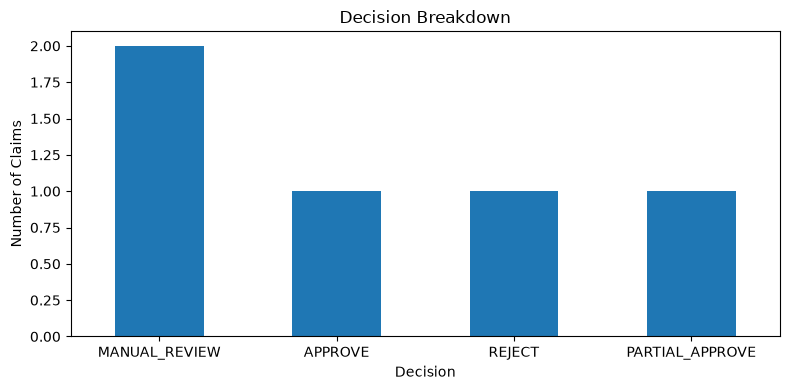

<Figure size 900x400 with 0 Axes>

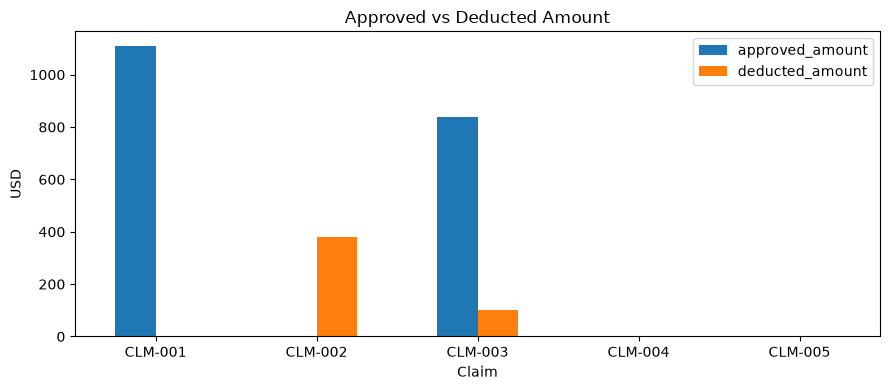

Total approved: 1950.0
Total deducted: 480.0


In [35]:
decision_counts = results_df["decision"].value_counts()

plt.figure(figsize=(8, 4))
decision_counts.plot(kind="bar")
plt.title("Decision Breakdown")
plt.xlabel("Decision")
plt.ylabel("Number of Claims")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

amount_df = results_df.set_index("claim_id")[["approved_amount", "deducted_amount"]]
plt.figure(figsize=(9, 4))
amount_df.plot(kind="bar", figsize=(9, 4))
plt.title("Approved vs Deducted Amount")
plt.xlabel("Claim")
plt.ylabel("USD")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Total approved:", round(results_df["approved_amount"].sum(), 2))
print("Total deducted:", round(results_df["deducted_amount"].sum(), 2))

## 10. Structured Output Validation

The final output must contain exactly these fields:

`claim_id, decision, approved_amount, deducted_amount, missing_docs, policy_refs, confidence, explanation, tools_used`

The validator below prevents accidental schema drift.


In [36]:
REQUIRED_FIELDS = [
    "claim_id", "decision", "approved_amount", "deducted_amount",
    "missing_docs", "policy_refs", "confidence", "explanation", "tools_used"
]
VALID_DECISIONS = {"APPROVE", "PARTIAL_APPROVE", "REJECT", "MANUAL_REVIEW"}

def validate_result(result: Dict[str, Any]) -> None:
    public = {k: v for k, v in result.items() if not k.startswith("_")}
    assert list(public.keys()) == REQUIRED_FIELDS, (
        f"Schema mismatch: {list(public.keys())}"
    )
    assert public["decision"] in VALID_DECISIONS
    assert isinstance(public["approved_amount"], (int, float))
    assert isinstance(public["deducted_amount"], (int, float))
    assert isinstance(public["missing_docs"], list)
    assert isinstance(public["policy_refs"], list)
    assert 0 <= public["confidence"] <= 1
    assert isinstance(public["tools_used"], list)

for r in results:
    validate_result(r)

print("All", len(results), "results passed schema validation.")

All 5 results passed schema validation.


## 11. Sample Outputs

At least three examples are shown below, as requested by the assignment.


In [37]:
for r in results[:3]:
    print(json.dumps({k:v for k,v in r.items() if not k.startswith("_")}, indent=2))

{
  "claim_id": "CLM-001",
  "decision": "APPROVE",
  "approved_amount": 1110.0,
  "deducted_amount": 0.0,
  "missing_docs": [],
  "policy_refs": [
    "POL-AIR-01",
    "POL-APR-01",
    "POL-APR-02",
    "POL-CAT-01",
    "POL-PD-01",
    "POL-PD-02",
    "POL-RCT-01"
  ],
  "confidence": 0.98,
  "explanation": "Claim is compliant and falls within the manager approval tier.",
  "tools_used": [
    "eligibility_check",
    "receipt_completeness_check",
    "limit_checker",
    "timeliness_check",
    "airfare_exception_check",
    "approval_threshold_checker",
    "policy_lookup",
    "policy_lookup",
    "policy_lookup",
    "policy_lookup"
  ]
}
{
  "claim_id": "CLM-002",
  "decision": "REJECT",
  "approved_amount": 0.0,
  "deducted_amount": 380.0,
  "missing_docs": [],
  "policy_refs": [
    "POL-APR-01",
    "POL-APR-02",
    "POL-CAT-02"
  ],
  "confidence": 0.98,
  "explanation": "All claimed items are ineligible under the travel reimbursement policy.",
  "tools_used": [
    "el

# Design Notes & Reasoning

### Why a hybrid agent?
Travel reimbursement is a financial decision. Groq is used as the LLM planning layer to inspect each claim and choose relevant tools. Reimbursement calculations and hard policy enforcement remain deterministic, so the LLM cannot invent caps or directly decide an amount.

### Why these tools?
- **Policy lookup:** grounds each category in a stable `POL-*` rule.
- **Eligibility check:** separates eligible from explicitly ineligible categories.
- **Receipt check:** handles mandatory receipt rules and produces missing-document evidence.
- **Limit checker:** performs reproducible per-diem calculations.
- **Approval threshold checker:** determines whether the amount is within agent authority.
- **Timeliness check:** catches claims outside the 30-day window.
- **Airfare exception check:** routes business/first-class airfare to Manual Review instead of silently deducting it.
- **Duplicate detector:** provides a basic fraud/error safeguard.

### Manual Review philosophy
The assignment explicitly prefers Manual Review over forcing a decision when information is missing, conflicting, exceptional, late, or above the approval authority. The implementation therefore treats those conditions as hard routing rules.

### Key trade-off
A fully autonomous LLM agent would be shorter, but less auditable for a reimbursement workflow. The hybrid approach is slightly more code but makes the money calculation deterministic and testable.

### Assumptions
1. For capped items, the assignment's explicit unit counts in the descriptions are used (`2 nights`, `3 days`, etc.).
2. For a Manual Review result, `approved_amount` and `deducted_amount` are set to `0` because the final disposition has not been determined by the human reviewer.
3. The assignment does not provide receipt IDs, vendors, or expense dates at line-item level, so duplicate detection is intentionally lightweight.
4. The supplied claim data is the source of truth; no external employee/company data is used.

### What I would improve next
- OCR receipt extraction and receipt-to-line-item matching
- Vendor/date/amount-based duplicate detection
- Persistent policy versioning and effective dates
- Human-review queue with approve/override actions
- Evaluation dataset with adversarial/ambiguous claims
- RAG over a larger policy repository
- MCP tools for external expense/receipt systems
- LangGraph state persistence and tracing
- Authentication, audit logging, and role-based approval

## 12. Final Required JSON Output

The final code cell below intentionally contains **only the required public fields** and emits one JSON object per claim.


In [38]:
final_results = [
    {k: r[k] for k in REQUIRED_FIELDS}
    for r in results
]

print(json.dumps(final_results, indent=2))

[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-AIR-01",
      "POL-APR-01",
      "POL-APR-02",
      "POL-CAT-01",
      "POL-PD-01",
      "POL-PD-02",
      "POL-RCT-01"
    ],
    "confidence": 0.98,
    "explanation": "Claim is compliant and falls within the manager approval tier.",
    "tools_used": [
      "eligibility_check",
      "receipt_completeness_check",
      "limit_checker",
      "timeliness_check",
      "airfare_exception_check",
      "approval_threshold_checker",
      "policy_lookup",
      "policy_lookup",
      "policy_lookup",
      "policy_lookup"
    ]
  },
  {
    "claim_id": "CLM-002",
    "decision": "REJECT",
    "approved_amount": 0.0,
    "deducted_amount": 380.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-APR-01",
      "POL-APR-02",
      "POL-CAT-02"
    ],
    "confidence": 0.98,
    "explanation": "All claime